# Carbon-24 — Pipeline 3 Tang

## Kien truc tong the

```
Raw data (10,153)
    |
    v  [TANG 1] HDBSCAN Noise Detection
    +---> Noise (786, 7.74%)  -->  Anomaly Analysis
    |
    v  Clean data (9,367, 92.26%)
    |
    v  [TANG 2] K-means Macro-clustering (k=3)
    +---> Ben vung (Low Energy)  : 3,213 (34.3%)
    +---> Trung gian             : 2,201 (23.5%)
    +---> Phuc tap (High Energy) : 3,953 (42.2%)
    |
    v  [TANG 3] GMM Micro-clustering (k=10)
    +---> 10 sub-clusters (polymorphs)
         Ben vung   -> GMM 2, 4, 7
         Trung gian -> GMM 0, 5, 8
         Phuc tap   -> GMM 1, 3, 4, 6, 9
```

## Nguyen tac
- **Tang 1**: HDBSCAN noise = Anomaly Detection cua de tai
- **Tang 2**: K-means tren du lieu sach = 3 nhom cau truc lon
- **Tang 3**: GMM tren du lieu sach = 10 phan nhom xac suat (polymorphs)
- Energy chi dung de **dien giai**, khong dung lam input


## 1. Setup & Chay Pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import Image, display as ipy_display

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Chay toan bo pipeline
import carbon24_pipeline_3tier
carbon24_pipeline_3tier.main()



CARBON-24 PIPELINE 3 TANG
Tier 1: HDBSCAN Noise  ->  Tier 2: K-means (k=3)  ->  Tier 3: GMM (k=10)
Output: c:\bda_env\venv\Scripts\DATAMINING\carbon24_pipeline_results
Loaded: (10153, 36)  |  structure features: 19

TANG 1: HDBSCAN NOISE DETECTION
  Noise  : 786  (7.74%)
  Clean  : 9,367  (92.26%)
  Energy noise: 0.3743  |  clean: 0.3008  |  diff: +0.0735
  -> Noise kem on dinh hon 0.0735 eV/atom

  Crystal system distribution (noise vs clean):
    monoclinic     : noise=40.1%  clean=47.6%
    triclinic      : noise=43.3%  clean=24.1%
    orthorhombic   : noise=10.7%  clean=17.1%
    trigonal       : noise=1.1%  clean=4.5%
    cubic          : noise=2.8%  clean=3.7%
    hexagonal      : noise=1.7%  clean=2.5%
    tetragonal     : noise=0.4%  clean=0.5%

  Saved: tier1_noise_analysis.csv  (786 rows)

TANG 2: K-MEANS MACRO-CLUSTERING  (k=3)
  Cluster distribution:
    Cluster 0: 2,201  (23.50%)
    Cluster 1: 3,953  (42.20%)
    Cluster 2: 3,213  (34.30%)
  [K-means] Silhouette=0.2777  

## 2. Load Ket Qua

In [2]:
OUT = Path('carbon24_pipeline_results')

final_df    = pd.read_csv(OUT / 'pipeline_final.csv')
noise_df    = pd.read_csv(OUT / 'tier1_noise_analysis.csv')
kmeans_df   = pd.read_csv(OUT / 'tier2_kmeans_clean.csv')
km_profile  = pd.read_csv(OUT / 'tier2_kmeans_profile.csv')
gmm_df      = pd.read_csv(OUT / 'tier3_gmm_clean.csv')
gmm_profile = pd.read_csv(OUT / 'tier3_gmm_profile.csv')

clean = final_df[final_df['pipeline_stage'] == 'clean'].copy()
noise = final_df[final_df['pipeline_stage'] == 'noise'].copy()

print(f'Final shape : {final_df.shape}')
print(f'Clean       : {len(clean):,}')
print(f'Noise       : {len(noise):,}')
final_df.head(3)


Final shape : (10153, 41)
Clean       : 9,367
Noise       : 786


,row_index,material_id,split,source_file,formula,elements,space_group_number,space_group_symbol,crystal_system,energy,...,min_bond_length,max_bond_length,std_coordination,min_coordination,max_coordination,kmeans_cluster,kmeans_label,gmm_cluster,gmm_probability,pipeline_stage
0,0,C-130499-1826-36,train,huggingface,C,C,12,C2/m,monoclinic,-154.311891,...,1.491934,1.569426,0.0,4.0,4.0,2,Ben vung (Low Energy),7,0.999997,clean
1,1,C-13904-4247-31,train,huggingface,C,C,12,C2/m,monoclinic,-154.332183,...,1.433922,1.592736,0.0,4.0,4.0,2,Ben vung (Low Energy),4,1.000000,clean
2,2,C-92138-4782-35,train,huggingface,C,C,8,Cm,monoclinic,-154.178157,...,1.462408,1.552865,0.4,3.0,4.0,1,Phuc tap (High Energy),6,0.999995,clean


## 3. Tong Quan Pipeline

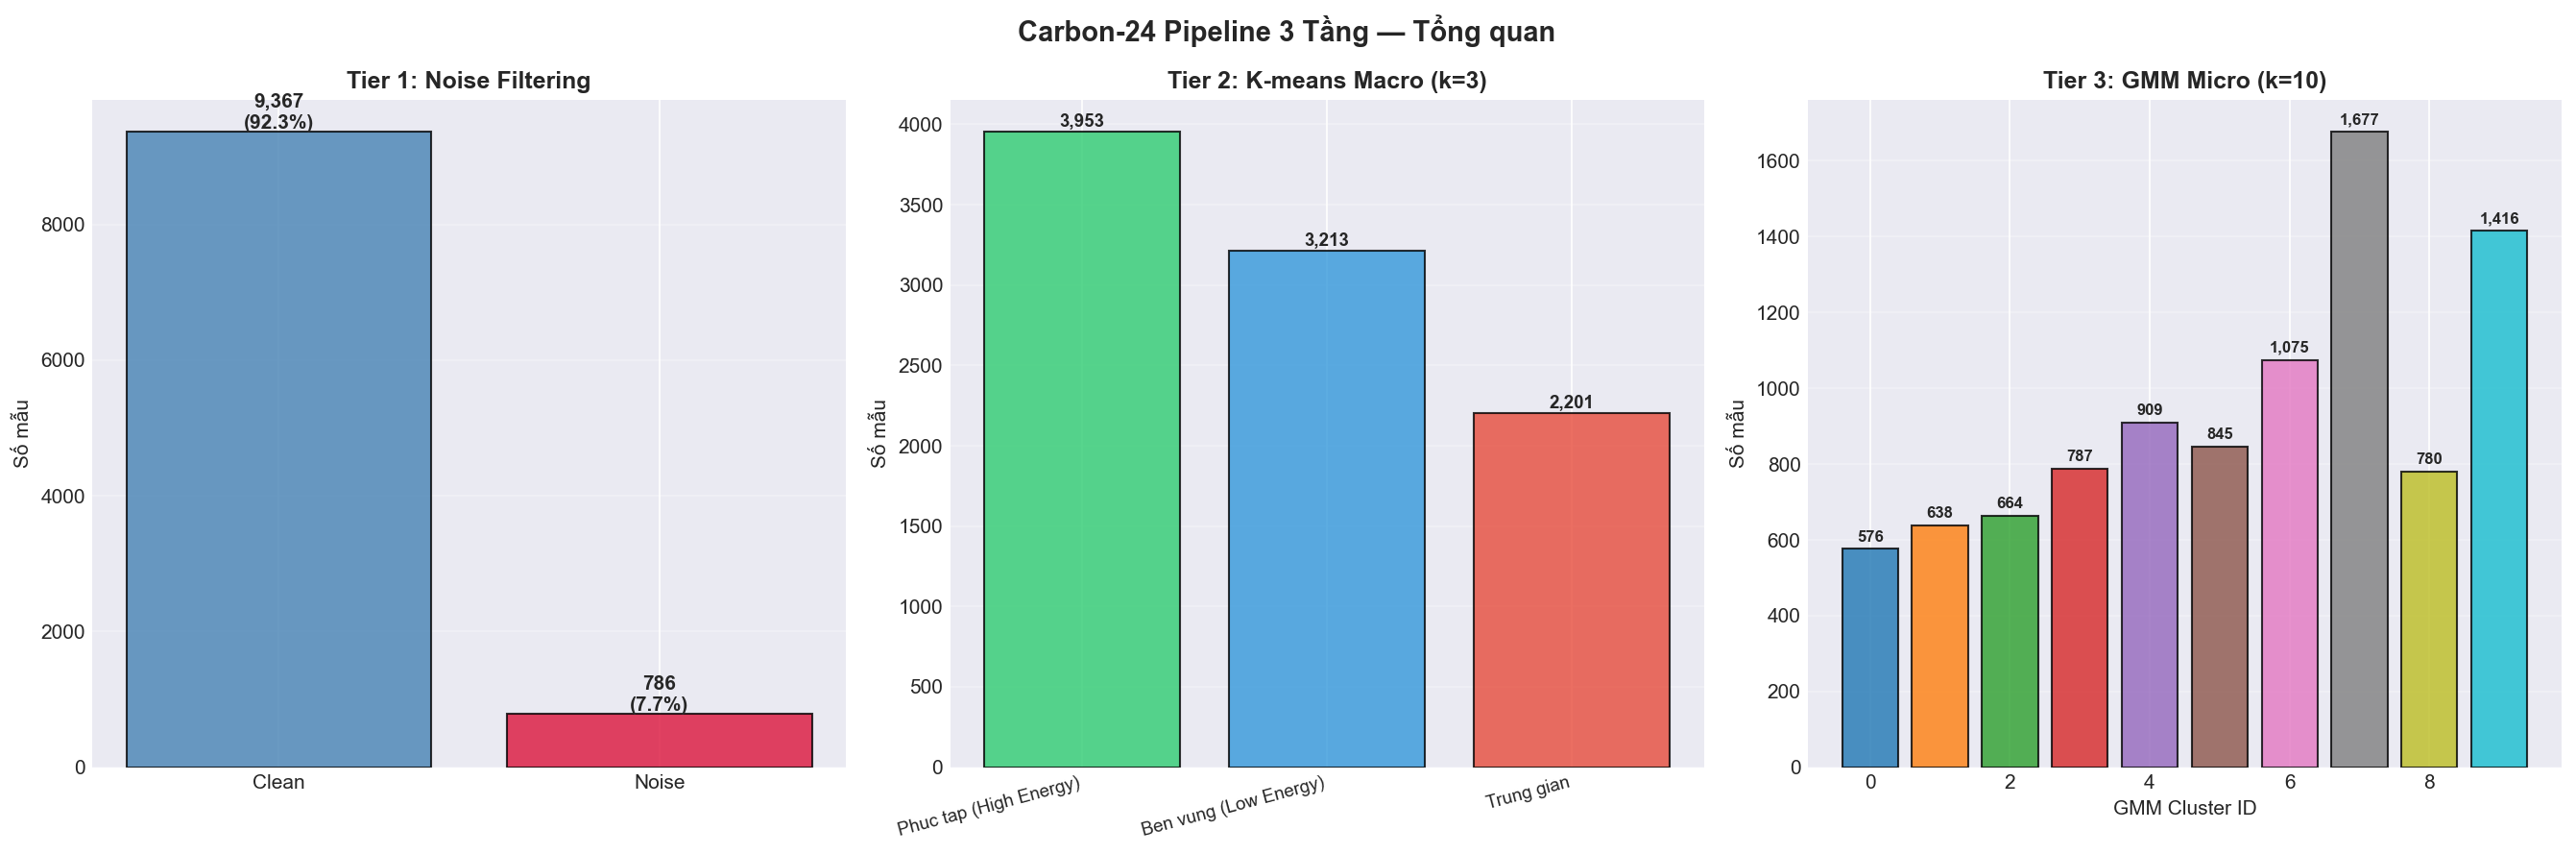

In [3]:
ipy_display(Image(filename=str(OUT / 'figures' / 'pipeline_overview.png')))


In [4]:
print('PIPELINE SUMMARY')
print('=' * 60)
print(f'  Total          : {len(final_df):,}')
print(f'  Noise (Tier 1) : {len(noise):,}  ({len(noise)/len(final_df):.2%})')
print(f'  Clean (Tier 2+): {len(clean):,}  ({len(clean)/len(final_df):.2%})')
print()
print('K-means macro-clusters:')
for lbl, n in clean['kmeans_label'].value_counts().items():
    print(f'  {lbl}: {n:,}  ({n/len(final_df):.2%})')
print()
print('GMM micro-clusters:')
for c, n in clean['gmm_cluster'].value_counts().sort_index().items():
    km_maj = gmm_df[gmm_df['gmm_cluster'] == c]['kmeans_label'].mode()[0]
    print(f'  GMM-{c}: {n:,}  ({n/len(final_df):.2%})  <- {km_maj}')


PIPELINE SUMMARY
  Total          : 10,153
  Noise (Tier 1) : 786  (7.74%)
  Clean (Tier 2+): 9,367  (92.26%)

K-means macro-clusters:
  Phuc tap (High Energy): 3,953  (38.93%)
  Ben vung (Low Energy): 3,213  (31.65%)
  Trung gian: 2,201  (21.68%)

GMM micro-clusters:
  GMM-0: 576  (5.67%)  <- Trung gian
  GMM-1: 638  (6.28%)  <- Phuc tap (High Energy)
  GMM-2: 664  (6.54%)  <- Ben vung (Low Energy)
  GMM-3: 787  (7.75%)  <- Phuc tap (High Energy)
  GMM-4: 909  (8.95%)  <- Ben vung (Low Energy)
  GMM-5: 845  (8.32%)  <- Trung gian
  GMM-6: 1,075  (10.59%)  <- Phuc tap (High Energy)
  GMM-7: 1,677  (16.52%)  <- Ben vung (Low Energy)
  GMM-8: 780  (7.68%)  <- Trung gian
  GMM-9: 1,416  (13.95%)  <- Phuc tap (High Energy)


## 4. Tang 1: HDBSCAN Noise Detection (Anomaly Analysis)

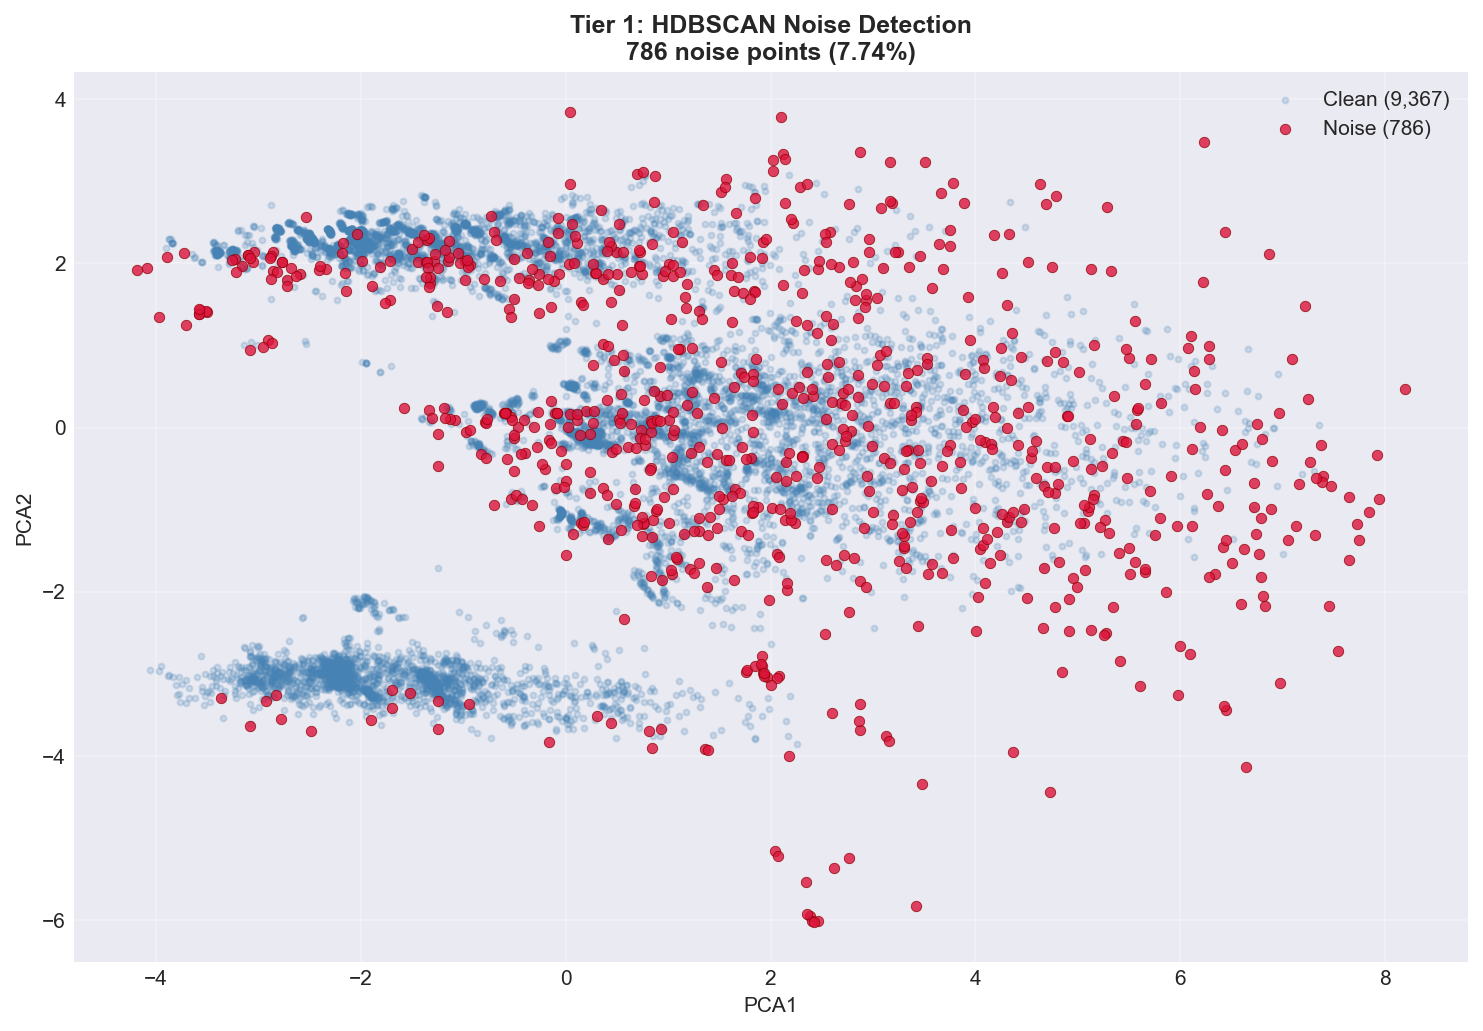

In [5]:
ipy_display(Image(filename=str(OUT / 'figures' / 'tier1_noise_pca.png')))


In [6]:
print('TANG 1: NOISE ANALYSIS')
print('=' * 60)
print(f'  Noise: {len(noise_df):,}  ({len(noise_df)/len(final_df):.2%})')
print()

e_noise = noise_df['relative_energy']
e_clean = final_df.loc[final_df['pipeline_stage'] == 'clean', 'relative_energy']
diff = e_noise.mean() - e_clean.mean()
print(f'  Energy noise : {e_noise.mean():.4f} +/- {e_noise.std():.4f}')
print(f'  Energy clean : {e_clean.mean():.4f} +/- {e_clean.std():.4f}')
print(f'  Difference   : {diff:+.4f} eV/atom  -> Noise kem on dinh hon')
print()

print('  Crystal system (noise vs clean):')
cs_n = noise_df['crystal_system'].value_counts(normalize=True) * 100
cs_c = final_df.loc[final_df['pipeline_stage'] == 'clean', 'crystal_system'].value_counts(normalize=True) * 100
for cs in cs_c.index:
    print(f'    {cs:<15}: noise={cs_n.get(cs, 0):.1f}%  clean={cs_c[cs]:.1f}%')


TANG 1: NOISE ANALYSIS
  Noise: 786  (7.74%)

  Energy noise : 0.3743 +/- 0.1077
  Energy clean : 0.3008 +/- 0.1371
  Difference   : +0.0735 eV/atom  -> Noise kem on dinh hon

  Crystal system (noise vs clean):
    monoclinic     : noise=40.1%  clean=47.6%
    triclinic      : noise=43.3%  clean=24.1%
    orthorhombic   : noise=10.7%  clean=17.1%
    trigonal       : noise=1.1%  clean=4.5%
    cubic          : noise=2.8%  clean=3.7%
    hexagonal      : noise=1.7%  clean=2.5%
    tetragonal     : noise=0.4%  clean=0.5%


In [9]:
# Boxplot energy: noise vs clean
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
ax.hist(e_clean, bins=60, alpha=0.5, color='steelblue', label=f'Clean ({len(e_clean):,})', density=True)
ax.hist(e_noise, bins=60, alpha=0.5, color='crimson',   label=f'Noise ({len(e_noise):,})', density=True)
ax.axvline(e_clean.mean(), color='steelblue', linestyle='--', lw=2, label=f'Clean mean={e_clean.mean():.4f}')
ax.axvline(e_noise.mean(), color='crimson',   linestyle='--', lw=2, label=f'Noise mean={e_noise.mean():.4f}')
ax.set_xlabel('Relative Energy (eV/atom)')
ax.set_ylabel('Density')
ax.set_title('Energy: Noise vs Clean', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Crystal system comparison
ax = axes[1]
cs_compare = pd.DataFrame({'Clean': cs_c, 'Noise': cs_n}).fillna(0)
cs_compare.plot(kind='bar', ax=ax, color=['steelblue', 'crimson'], alpha=0.8, edgecolor='black')
ax.set_xlabel('Crystal System')
ax.set_ylabel('Percentage (%)')
ax.set_title('Crystal System: Noise vs Clean', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()


## 5. Tang 2: K-means Macro-clustering (k=3)

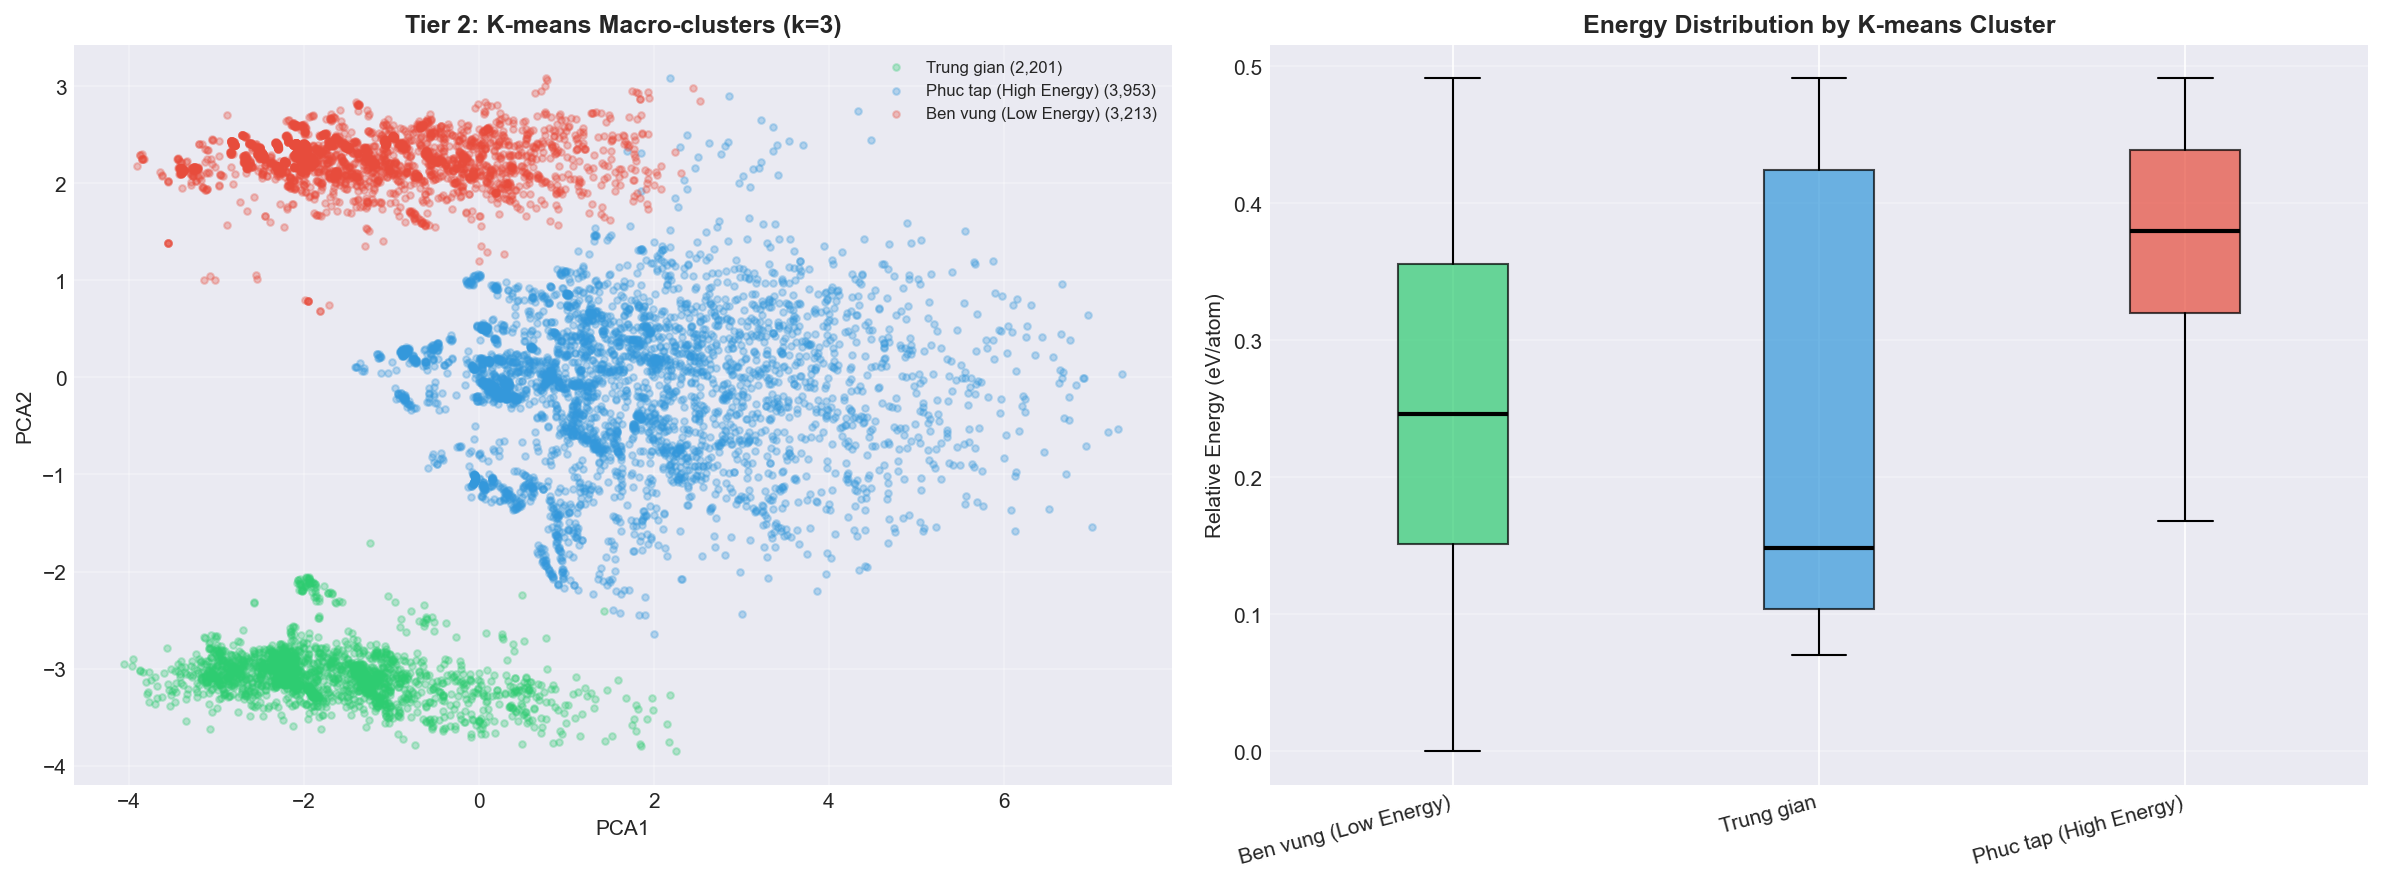

In [10]:
ipy_display(Image(filename=str(OUT / 'figures' / 'tier2_kmeans.png')))


In [11]:
print('TANG 2: K-MEANS MACRO-CLUSTERS')
print('=' * 60)
for lbl in clean['kmeans_label'].unique():
    sub = clean[clean['kmeans_label'] == lbl]
    e = sub['relative_energy']
    print(f'  {lbl}')
    print(f'    N      = {len(sub):,}  ({len(sub)/len(clean):.2%} of clean)')
    print(f'    Energy : mean={e.mean():.4f}  std={e.std():.4f}  median={e.median():.4f}')
    if 'crystal_system' in sub.columns:
        top_cs = sub['crystal_system'].value_counts().head(3)
        print(f'    Top crystal systems: {top_cs.to_dict()}')
    print()


TANG 2: K-MEANS MACRO-CLUSTERS
  Ben vung (Low Energy)
    N      = 3,213  (34.30% of clean)
    Energy : mean=0.2392  std=0.1386  median=0.2465
    Top crystal systems: {'monoclinic': 1377, 'orthorhombic': 703, 'triclinic': 361}

  Phuc tap (High Energy)
    N      = 3,953  (42.20% of clean)
    Energy : mean=0.3766  std=0.0718  median=0.3801
    Top crystal systems: {'monoclinic': 2221, 'triclinic': 967, 'orthorhombic': 760}

  Trung gian
    N      = 2,201  (23.50% of clean)
    Energy : mean=0.2546  std=0.1574  median=0.1487
    Top crystal systems: {'triclinic': 933, 'monoclinic': 861, 'trigonal': 261}



In [12]:
# Heatmap profile K-means
num_cols = ['relative_energy', 'volume_per_atom', 'mean_bond_length',
            'std_coordination', 'angle_deviation', 'num_atoms']
num_cols = [c for c in num_cols if c in clean.columns]

profile = clean.groupby('kmeans_label')[num_cols].mean()
profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(profile_norm, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalized'})
ax.set_title('K-means Cluster Profile (normalized)', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nRaw means:')
display(profile.round(4))



Raw means:


,relative_energy,volume_per_atom,mean_bond_length,std_coordination,angle_deviation,num_atoms
kmeans_label,,,,,,
Ben vung (Low Energy),0.2392,5.7316,1.5277,0.0000,41.0991,8.1152
Phuc tap (High Energy),0.3766,6.4088,1.4889,0.4444,36.6027,10.0390
Trung gian,0.2546,7.2137,1.4061,0.0000,43.8863,7.8019


## 6. Tang 3: GMM Micro-clustering (k=10)

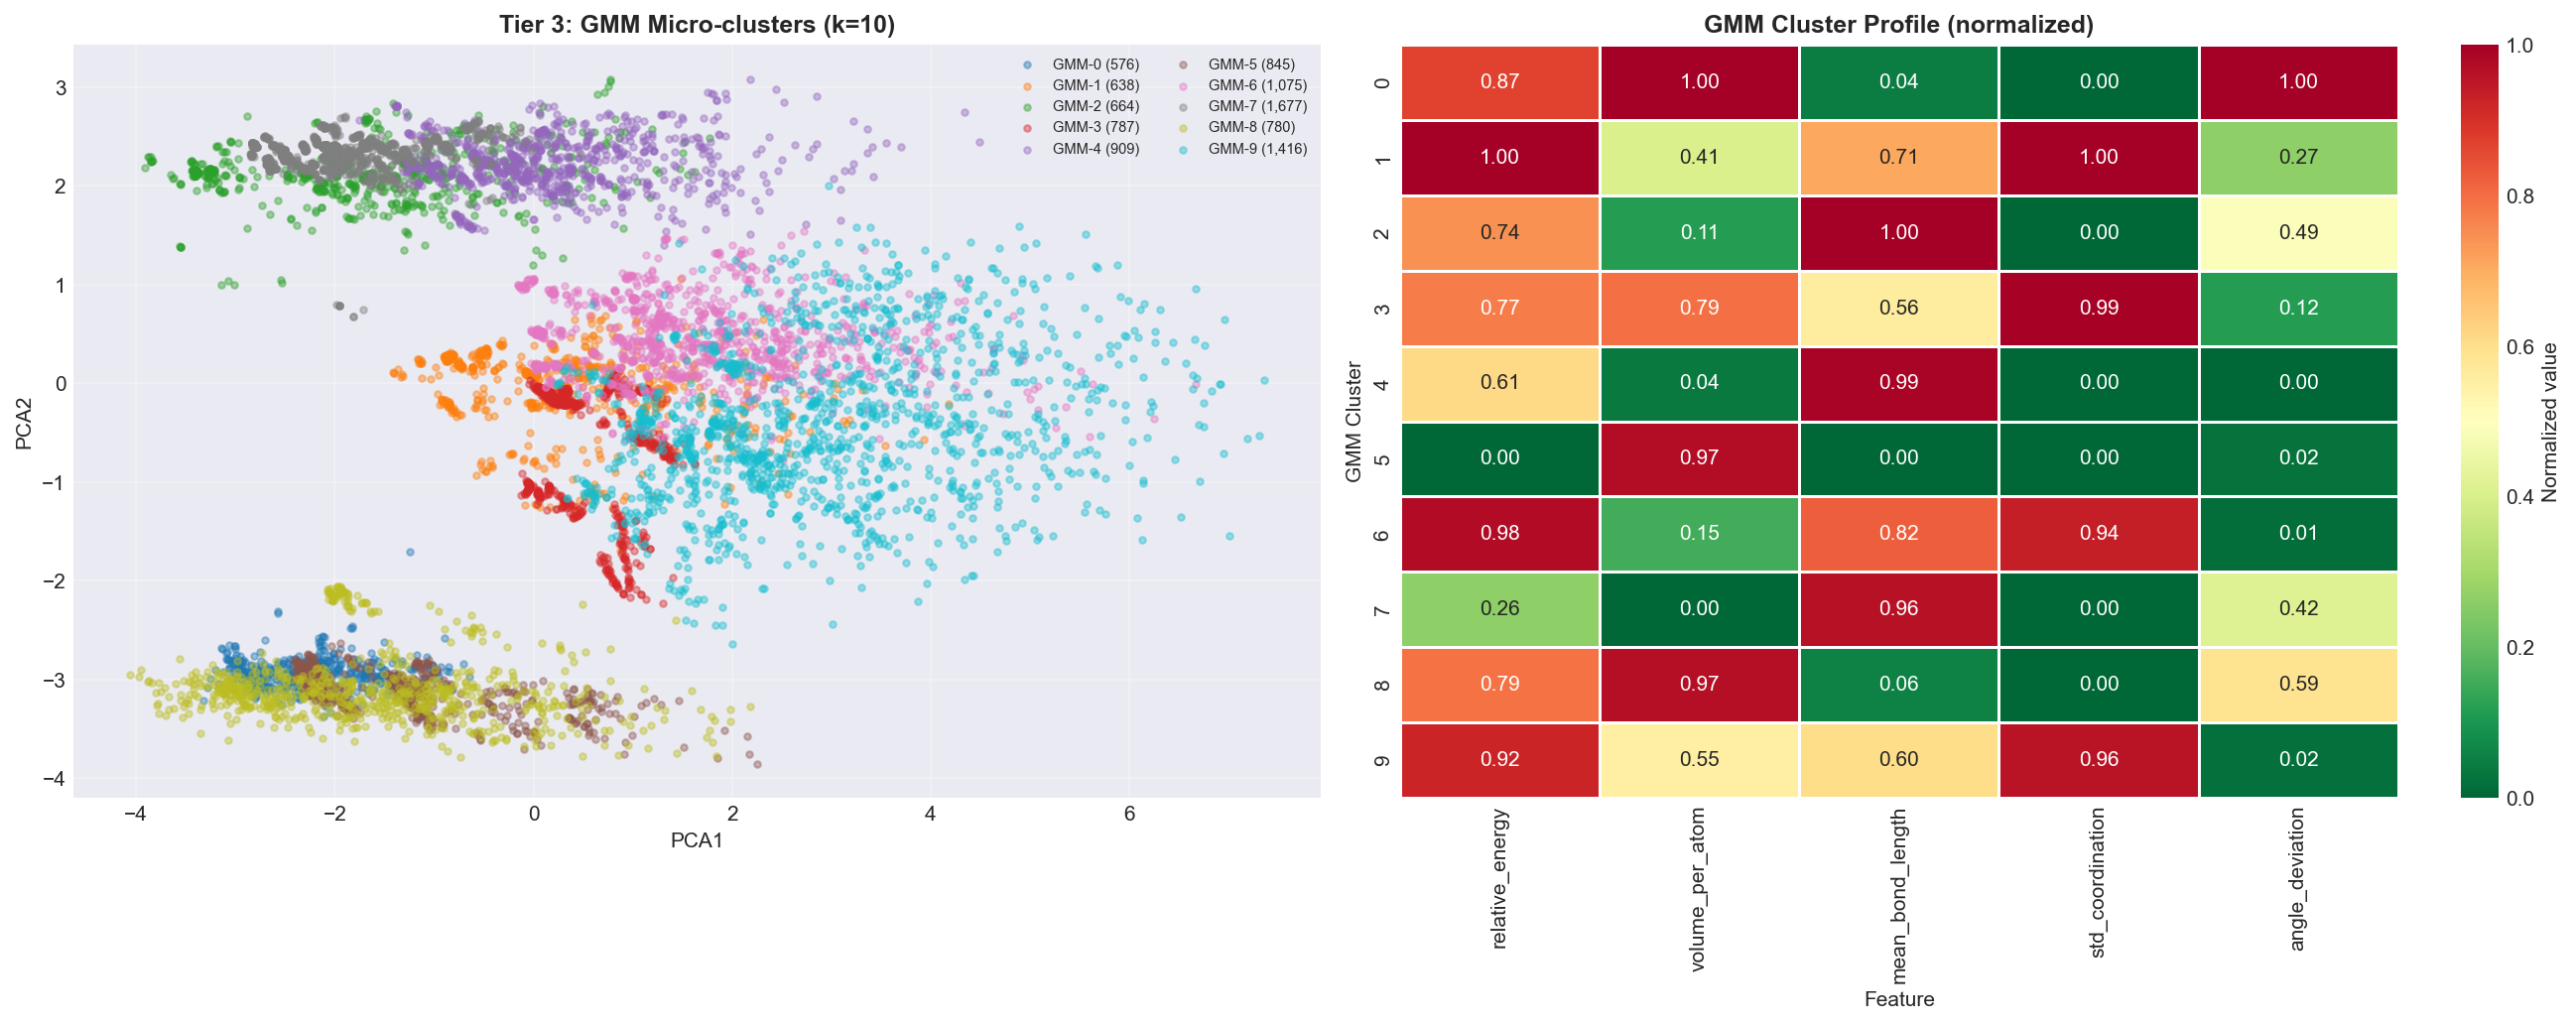

In [13]:
ipy_display(Image(filename=str(OUT / 'figures' / 'tier3_gmm.png')))


In [14]:
print('TANG 3: GMM MICRO-CLUSTERS')
print('=' * 65)
print(f"{'GMM':<8} {'K-means Macro':<32} {'N':>6} {'Energy':>10} {'Prob':>8}")
print('-' * 65)
for c in sorted(gmm_df['gmm_cluster'].unique()):
    sub    = gmm_df[gmm_df['gmm_cluster'] == c]
    km_maj = sub['kmeans_label'].mode()[0]
    e      = sub['relative_energy'].mean()
    p      = sub['gmm_probability'].mean()
    print(f'  GMM-{c:<4} {km_maj:<32} {len(sub):>6,} {e:>10.4f} {p:>8.3f}')


TANG 3: GMM MICRO-CLUSTERS
GMM      K-means Macro                         N     Energy     Prob
-----------------------------------------------------------------
  GMM-0    Trung gian                          576     0.3613    0.988
  GMM-1    Phuc tap (High Energy)              638     0.4004    1.000
  GMM-2    Ben vung (Low Energy)               664     0.3248    1.000
  GMM-3    Phuc tap (High Energy)              787     0.3336    0.999
  GMM-4    Ben vung (Low Energy)               909     0.2851    1.000
  GMM-5    Trung gian                          845     0.1045    1.000
  GMM-6    Phuc tap (High Energy)            1,075     0.3933    0.982
  GMM-7    Ben vung (Low Energy)             1,677     0.1825    0.998
  GMM-8    Trung gian                          780     0.3383    0.994
  GMM-9    Phuc tap (High Energy)            1,416     0.3781    0.992


In [15]:
# Heatmap GMM profile
num_cols = ['relative_energy', 'volume_per_atom', 'mean_bond_length',
            'std_coordination', 'angle_deviation', 'num_atoms']
num_cols = [c for c in num_cols if c in gmm_profile.columns]

profile_sub  = gmm_profile[num_cols].copy()
profile_norm = (profile_sub - profile_sub.min()) / (profile_sub.max() - profile_sub.min() + 1e-9)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(profile_norm, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalized'})
ax.set_title('GMM Micro-cluster Profile (normalized)', fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('GMM Cluster')
plt.tight_layout()
plt.show()


In [16]:
# GMM sub-clusters within each K-means macro
print('GMM sub-clusters within each K-means macro-cluster:')
print('=' * 55)
for km_lbl in clean['kmeans_label'].unique():
    sub = gmm_df[gmm_df['kmeans_label'] == km_lbl]
    gmm_dist = sub['gmm_cluster'].value_counts().sort_index()
    print(f'  {km_lbl}:')
    for gid, cnt in gmm_dist.items():
        e = sub[sub['gmm_cluster'] == gid]['relative_energy'].mean()
        p = sub[sub['gmm_cluster'] == gid]['gmm_probability'].mean()
        print(f'    GMM-{gid}: {cnt:,}  energy={e:.4f}  prob={p:.3f}')
    print()


GMM sub-clusters within each K-means macro-cluster:
  Ben vung (Low Energy):
    GMM-2: 664  energy=0.3248  prob=1.000
    GMM-4: 872  energy=0.2830  prob=1.000
    GMM-7: 1,677  energy=0.1825  prob=0.998

  Phuc tap (High Energy):
    GMM-1: 638  energy=0.4004  prob=1.000
    GMM-3: 787  energy=0.3336  prob=0.999
    GMM-4: 37  energy=0.3352  prob=1.000
    GMM-6: 1,075  energy=0.3933  prob=0.982
    GMM-9: 1,416  energy=0.3781  prob=0.992

  Trung gian:
    GMM-0: 576  energy=0.3613  prob=0.988
    GMM-5: 845  energy=0.1045  prob=1.000
    GMM-8: 780  energy=0.3383  prob=0.994



## 7. Ket Luan & Y Nghia

In [17]:
n_noise = len(noise_df)
n_total = len(final_df)
n_clean = len(clean)

print('=' * 65)
print('KET LUAN PIPELINE 3 TANG')
print('=' * 65)

print(f'''
1. TANG 1 - Anomaly Detection (HDBSCAN Noise):
   - {n_noise:,} cau truc bat thuong ({n_noise/n_total:.2%})
   - Kem on dinh hon +0.0735 eV/atom so voi cau truc binh thuong
   - Triclinic chiem ty le cao bat thuong (43.3% vs 24.1%)
   - Day la phan "phat hien di biet" cua de tai

2. TANG 2 - Macro-clustering (K-means k=3):
   - {n_clean:,} cau truc sach ({n_clean/n_total:.2%})
   - 3 nhom lon phan anh 3 che do cau truc khac nhau
   - Silhouette = 0.2777 (phu hop voi du lieu phuc tap)

3. TANG 3 - Micro-clustering (GMM k=10):
   - 10 sub-clusters (polymorphs) voi xac suat membership
   - BIC = -357009 (mo hinh hoi tu tot)
   - Moi nhom lon duoc be nho thanh 2-5 phan nhom
   - Phan anh su da dang cau truc trong moi nhom

=> Pipeline tra loi day du cho ten de tai:
   Phat hien di biet va phan cum cau truc Carbon-24
''')


KET LUAN PIPELINE 3 TANG

1. TANG 1 - Anomaly Detection (HDBSCAN Noise):
   - 786 cau truc bat thuong (7.74%)
   - Kem on dinh hon +0.0735 eV/atom so voi cau truc binh thuong
   - Triclinic chiem ty le cao bat thuong (43.3% vs 24.1%)
   - Day la phan "phat hien di biet" cua de tai

2. TANG 2 - Macro-clustering (K-means k=3):
   - 9,367 cau truc sach (92.26%)
   - 3 nhom lon phan anh 3 che do cau truc khac nhau
   - Silhouette = 0.2777 (phu hop voi du lieu phuc tap)

3. TANG 3 - Micro-clustering (GMM k=10):
   - 10 sub-clusters (polymorphs) voi xac suat membership
   - BIC = -357009 (mo hinh hoi tu tot)
   - Moi nhom lon duoc be nho thanh 2-5 phan nhom
   - Phan anh su da dang cau truc trong moi nhom

=> Pipeline tra loi day du cho ten de tai:
   Phat hien di biet va phan cum cau truc Carbon-24

